Step 1: Loading and inspecting the data

In [1]:
import pandas as pd

data = pd.read_csv('../rawDataset/FireAlarmSprinklerData.csv')
additional_data = pd.read_csv('../rawDataset/MoreFireAlarmSprinklerData.csv') # Additional data provided by client

print("\nFirst data info\n")
print(data.info())
print("\nAdditional data info\n")
print(additional_data.info())

print("\nFirst data head\n")
print(data.head())
print("\nAdditional data head\n")
print(additional_data.head())

print("\nFirst data description\n")
print(data.describe())
print("\nAdditional data description\n")
print(additional_data.describe())



First data info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 484 entries, 0 to 483
Data columns (total 10 columns):
 #   Column                                                                                                                                                         Non-Null Count  Dtype 
---  ------                                                                                                                                                         --------------  ----- 
 0   ID                                                                                                                                                             484 non-null    int64 
 1   Assessment Date                                                                                                                                                484 non-null    object
 2   Address                                                                                                                     

Step 2: Shortening the feature names

In [2]:
data_columns = [
    "ID",
    "Assessment_Date",
    "Address",
    "Unit",
    "Multi_Unit_Alarm_System",
    "Building_Sprinklered",
    "Fire_Extinguishers",
    "Building_Alarm_System",
    "Building_Sprinklered_2",
    "Fire_Extinguishers_2"
]

additional_data_columns = [
    "Assessment_Date",
    "Address",
    "Building_Alarm_System",
    "Building_Sprinklered_2",
    "Fire_Extinguishers_2"
]

data.columns = data_columns
additional_data.columns = additional_data_columns

print(data.columns)
print(additional_data.columns)
print(additional_data.head())


Index(['ID', 'Assessment_Date', 'Address', 'Unit', 'Multi_Unit_Alarm_System',
       'Building_Sprinklered', 'Fire_Extinguishers', 'Building_Alarm_System',
       'Building_Sprinklered_2', 'Fire_Extinguishers_2'],
      dtype='object')
Index(['Assessment_Date', 'Address', 'Building_Alarm_System',
       'Building_Sprinklered_2', 'Fire_Extinguishers_2'],
      dtype='object')
  Assessment_Date                Address Building_Alarm_System  \
0      21/09/2021          75 Carol Road                   Yes   
1      21/09/2021    125 Bayfield Street                   Yes   
2      22/09/2021  500 Mapleview Drive W                   Yes   
3      24/09/2021           1 Bernick dr                   Yes   
4      27/09/2021    15 cheltenham road                    Yes   

  Building_Sprinklered_2 Fire_Extinguishers_2  
0                     No                  Yes  
1                    Yes                  Yes  
2                    Yes                  Yes  
3                    Yes         

Step 3: Dropping Specified Column

In [3]:
data = data.drop(columns=["ID","Unit","Multi_Unit_Alarm_System", "Building_Sprinklered", "Fire_Extinguishers"])

data.columns = data.columns.str.replace('_2', '')

additional_data.columns = additional_data.columns.str.replace('_2', '')

for column in set(data.columns) - set(additional_data.columns):
    additional_data[column] = None

additional_data = additional_data[data.columns]

merged_data = pd.concat([data, additional_data], ignore_index=True)

print(merged_data.info())
print(merged_data.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1120 entries, 0 to 1119
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Assessment_Date        679 non-null    object
 1   Address                679 non-null    object
 2   Building_Alarm_System  550 non-null    object
 3   Building_Sprinklered   551 non-null    object
 4   Fire_Extinguishers     551 non-null    object
dtypes: object(5)
memory usage: 43.9+ KB
None
  Assessment_Date          Address Building_Alarm_System Building_Sprinklered  \
0      06/09/2023  155 Dunlop St W                   Yes                  Yes   
1      10/09/2023  155 Dunlop st w                   Yes                  Yes   
2      10/09/2023              123                   NaN                  NaN   
3      20/09/2023        201 Hurst                   NaN                  NaN   
4      20/09/2023        201 Hurst                   NaN                  NaN   

  Fi

Step 4: Clean Data

In [4]:
yes_no_columns = [
    "Building_Alarm_System",
    "Building_Sprinklered",
    "Fire_Extinguishers"
]

for column in yes_no_columns:
    merged_data[column].fillna('No', inplace=True)

merged_data.fillna(method='ffill', inplace=True)

merged_data.drop_duplicates(inplace=True)

merged_data['Assessment_Date'] = pd.to_datetime(merged_data['Assessment_Date'], errors='coerce', dayfirst=True)

cleaned_data_summary = merged_data.describe()
print(cleaned_data_summary)
print(merged_data.head())


                  Assessment_Date
count                         625
mean   2023-06-18 10:54:20.160000
min           2002-02-24 00:00:00
25%           2022-03-24 00:00:00
50%           2023-12-22 00:00:00
75%           2024-03-05 00:00:00
max           2024-05-29 00:00:00
  Assessment_Date                Address Building_Alarm_System  \
0      2023-09-06        155 Dunlop St W                   Yes   
1      2023-09-10        155 Dunlop st w                   Yes   
2      2023-09-10                    123                    No   
3      2023-09-20              201 Hurst                    No   
5      2023-10-05  15 cedar point drive                    Yes   

  Building_Sprinklered Fire_Extinguishers  
0                  Yes                Yes  
1                  Yes                Yes  
2                   No                 No  
3                   No                 No  
5                   No                Yes  


/var/folders/9_/9s4s12cs7973rzn1vzlc83s40000gn/T/ipykernel_1926/1263798455.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged_data.fillna(method='ffill', inplace=True)


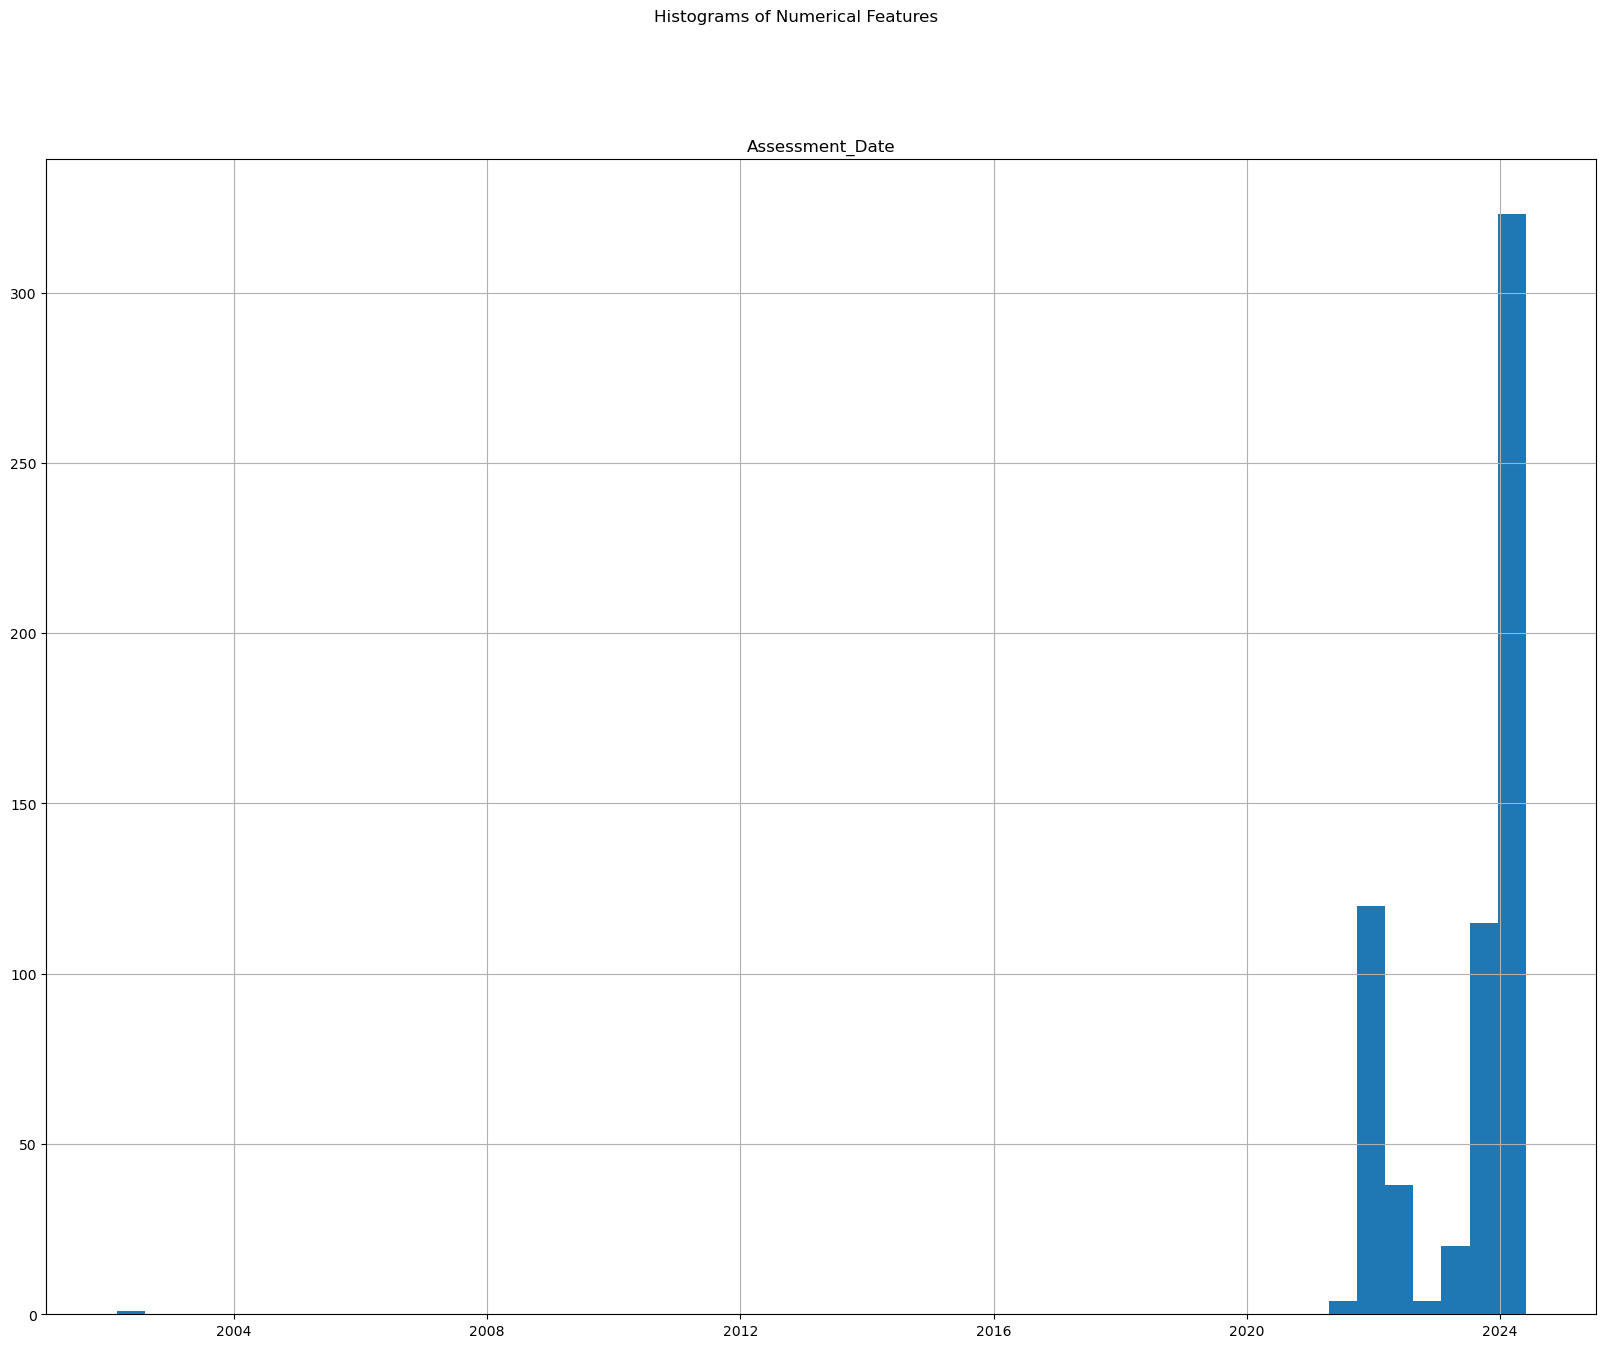

In [5]:
import matplotlib.pyplot as plt

merged_data.hist(bins=50, figsize=(20, 15))
plt.suptitle('Histograms of Numerical Features')
plt.show()


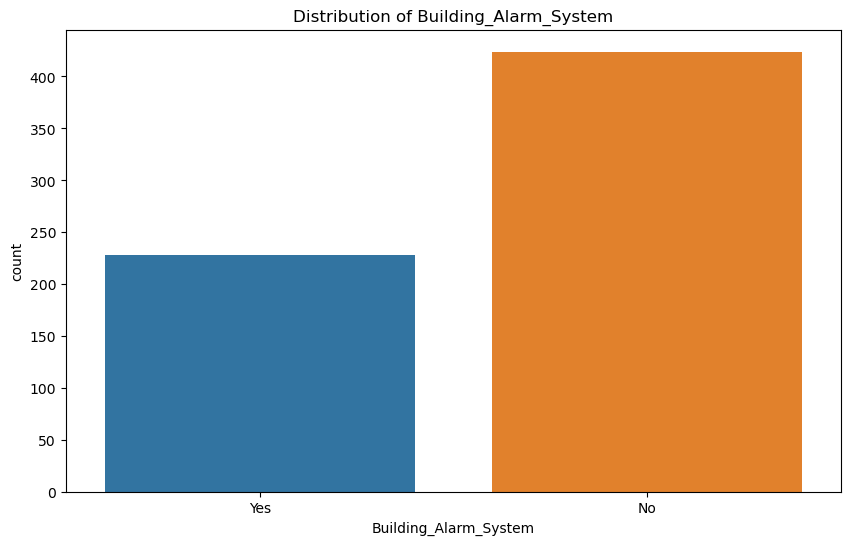

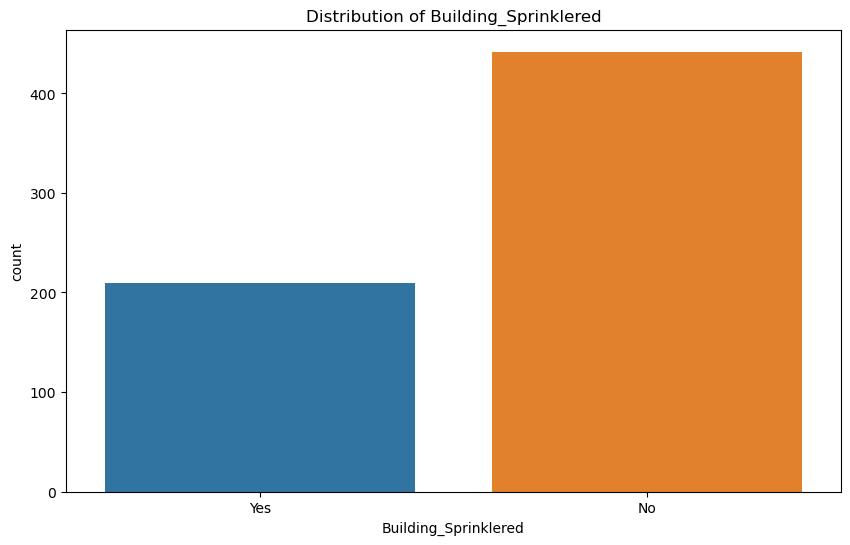

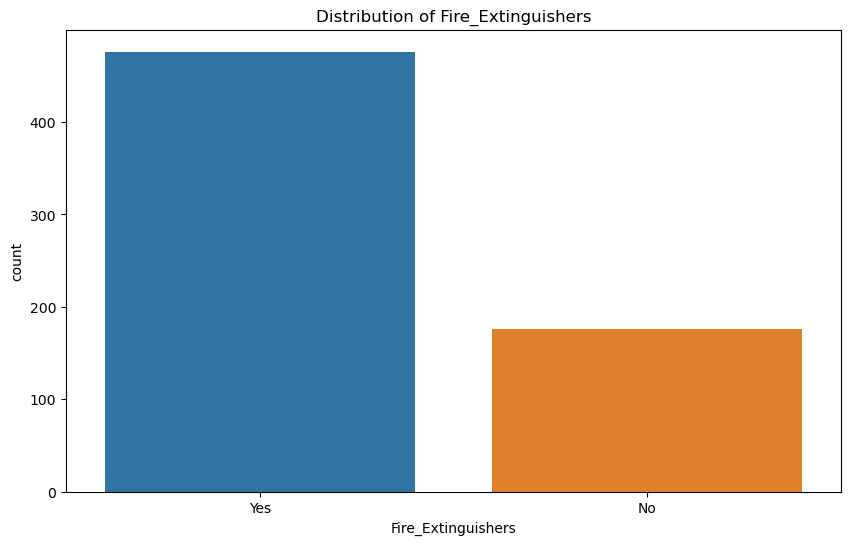

In [6]:
import seaborn as sns

for column in yes_no_columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=column, data=merged_data)
    plt.title(f'Distribution of {column}')
    plt.show()


In [7]:
from geopy.geocoders import Nominatim

geo_converted_data = merged_data

geolocator = Nominatim(user_agent="Geopy Library")

def geocode_address(address):
    try:
        location = geolocator.geocode(address)
        print("\nLocation found\n")
        print("Lat:")
        print(location.latitude)
        return (location.latitude, location.longitude) if location else (0, 0)
    except Exception as e:
        print(f"Error geocoding {address}: {e}")
        return (0, 0)

geo_converted_data['LatLong'] = geo_converted_data['Address'].apply(geocode_address)
geo_converted_data[['Latitude', 'Longitude']] = pd.DataFrame(geo_converted_data['LatLong'].tolist(), index=geo_converted_data.index)

geo_converted_data[['Address', 'Latitude', 'Longitude']].head()



Location found

Lat:
44.3858466

Location found

Lat:
44.3858466

Location found

Lat:
31.9059024

Location found

Lat:
32.540519700000004

Location found

Lat:
40.68521945

Location found

Lat:
40.68521945

Location found

Lat:
44.3703772

Location found

Lat:
44.409284

Location found

Lat:
44.3237692

Location found

Lat:
40.6857408

Location found

Lat:
40.6857408

Location found

Lat:
53.9769374

Location found

Lat:
42.629403100000005

Location found

Lat:
52.4201595

Location found

Lat:
32.462013188194575

Location found

Lat:
44.3507158

Location found

Lat:
44.3507158

Location found

Lat:
44.3507158

Location found

Lat:
41.686789881945664

Location found

Lat:
44.4097443

Location found

Lat:
44.2703585

Location found

Lat:
44.3237692

Location found

Lat:
44.4025393

Location found

Lat:
44.35754265132782

Location found

Lat:
44.35754265132782

Location found

Lat:
44.35754265132782

Location found

Lat:
44.4088922

Location found

Lat:
44.409284

Location found

Lat:
4

,Address,Latitude,Longitude
0,155 Dunlop St W,44.385847,-79.697574
1,155 Dunlop st w,44.385847,-79.697574
2,123,31.905902,35.198435
3,201 Hurst,32.540520,-97.298732
5,15 cedar point drive,40.685219,-73.288698


In [8]:
geo_converted_data.drop_duplicates(inplace=True)

In [18]:
import re
data = geo_converted_data
def has_numeric(address):
    return bool(re.search(r'\d+\s+\D+', address))

def remove_test_rows(df):
    return df[~df.apply(lambda row: row.astype(str).str.contains('test', case=False).any(), axis=1)]

def remove_zero_latlong(df):
    return df[(df['Latitude'] != 0.0) & (df['Longitude'] != 0.0)]

filtered_data = data[data['Address'].apply(has_numeric)]
filtered_data = remove_test_rows(filtered_data)
final_cleaned_data = remove_zero_latlong(filtered_data)


In [20]:
final_cleaned_data.to_csv('final_cleaned_sprinkler_data.csv', index=False)